# Part 1: Handling missing values & Basic concepts in Probability

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [14]:
df = pd.read_csv('Cars.csv')
print("Dataset Dimensions (rows, columns): ", df.shape, '\n')
print("Data Sample: ", '\n', df.head(), '\n')

Dataset Dimensions (rows, columns):  (205, 24) 

Data Sample:  
                     carname fueltype aspiration doornumber      carbody  \
0        alfa-romero giulia      gas        std        two  convertible   
1       alfa-romero stelvio      gas        std        two  convertible   
2  alfa-romero Quadrifoglio      gas        std        two    hatchback   
3               audi 100 ls      gas        std       four        sedan   
4                audi 100ls      gas        std       four        sedan   

  drivewheel enginelocation  wheelbase  carlength  carwidth  ...  enginesize  \
0        rwd          front       88.6      168.8      64.1  ...       130.0   
1        rwd          front       88.6      168.8      64.1  ...       130.0   
2        rwd          front       94.5      171.2      65.5  ...       152.0   
3        fwd          front       99.8      176.6      66.2  ...       109.0   
4        4wd          front       99.4      176.6      66.4  ...       136.0   

   

In [15]:
print("Description for qualitative data: ", '\n', df.describe(include='object'), '\n')
print("Description for quantitative data: ", '\n', df.describe(), '\n')

Description for qualitative data:  
               carname fueltype aspiration doornumber carbody drivewheel  \
count             205      205        205        205     205        205   
unique            147        2          2          2       5          3   
top     toyota corona      gas        std       four   sedan        fwd   
freq                6      185        168        115      96        120   

       enginelocation enginetype cylindernumber fuelsystem  
count             205        205            205        205  
unique              2          7              7          8  
top             front        ohc           four       mpfi  
freq              202        148            159         94   

Description for quantitative data:  
         wheelbase   carlength    carwidth   carheight   curbweight  \
count  194.000000  205.000000  185.000000  190.000000   205.000000   
mean    98.669588  174.049268   65.932973   53.738947  2555.565854   
std      5.934168   12.337289   

In [16]:
# Q1: How many null values are there in each column?
print("Null values in each column: ", '\n', df.isnull().sum(), '\n')

Null values in each column:  
 carname              0
fueltype             0
aspiration           0
doornumber           0
carbody              0
drivewheel           0
enginelocation       0
wheelbase           11
carlength            0
carwidth            20
carheight           15
curbweight           0
enginetype           0
cylindernumber       0
enginesize          20
fuelsystem           0
boreratio            0
stroke               0
compressionratio     0
horsepower           0
peakrpm              0
citympg              0
highwaympg           0
price                0
dtype: int64 



In [17]:
# Q1_1: Replace the null value of column "wheelbase" with the max value of the same column
max_wheelbase = df['wheelbase'].max()
df['wheelbase'].fillna(max_wheelbase, inplace=True)
print("Null values in 'wheelbase' column after replacement: ", df['wheelbase'].isnull().sum(), '\n')

Null values in 'wheelbase' column after replacement:  0 



/var/folders/f6/znr63jp935l62lz25vwtfqyr0000gn/T/ipykernel_97515/2383300359.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['wheelbase'].fillna(max_wheelbase, inplace=True)


In [22]:
# Q1_2: Replace the null value of column "carwidth" with the Min value of the same column
min_carwidth = df['carwidth'].min()
df['carwidth'].fillna(min_carwidth, inplace=True)
print("Null values in 'carwidth' column after replacement: ", df['carwidth'].isnull().sum())

Null values in 'carwidth' column after replacement:  205


/var/folders/f6/znr63jp935l62lz25vwtfqyr0000gn/T/ipykernel_97515/1855260699.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['carwidth'].fillna(min_carwidth, inplace=True)
/var/folders/f6/znr63jp935l62lz25vwtfqyr0000gn/T/ipykernel_97515/1855260699.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['ca

In [24]:
# Q1_3: Use Linear Interpolation to change the null value of column "carheight"
df['carheight'] = df['carheight'].interpolate(method='linear')

print("Null values in 'carheight' after interpolation:", df['carheight'].isnull().sum())

Null values in 'carheight' after interpolation: 0


In [26]:
# Q1_4: Replace the null value of column "enginesize" with the mod of the same column and check how many null values we have
mod_enginesize = df['enginesize'].mode()[0]
df['enginesize'].fillna(mod_enginesize, inplace=True)
print("Null values in 'enginesize' column after replacement: ", df['enginesize'].isnull().sum())

Null values in 'enginesize' column after replacement:  0


/var/folders/f6/znr63jp935l62lz25vwtfqyr0000gn/T/ipykernel_97515/1934193170.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['enginesize'].fillna(mod_enginesize, inplace=True)


In [28]:
# Q2: What is the Probability that the Car is Sedan ? (1 mark)
total_cars = len(df)
sedan_cars = len(df[df['carbody'] == 'sedan'])
probability_sedan = sedan_cars / total_cars
print(f"Probability that the Car is Sedan: {probability_sedan}")

Probability that the Car is Sedan: 0.4682926829268293


In [30]:
# Q3: What is the Probability that the car is Sedan and works with gas ?
sedan_with_gas = len(df[(df['carbody'] == 'sedan') & (df['fueltype'] == 'gas')])
probability_sedan_gas = sedan_with_gas / total_cars
print(f"Probability that the car is Sedan and works with gas: {probability_sedan_gas}")

Probability that the car is Sedan and works with gas: 0.3951219512195122


In [31]:
# Q4:What is the probability that a car is Sedan given it is a gas fuel type?
gas_cars = len(df[df['fueltype'] == 'gas'])
probability_sedan_given_gas = sedan_with_gas / gas_cars
print(f"Probability that a car is Sedan given it is a gas fuel type: {probability_sedan_given_gas}")

Probability that a car is Sedan given it is a gas fuel type: 0.43783783783783786


In [32]:
# Q5: Given that the car height is higer than 50, find the probability that the car engin size is greater than 130?
height_greater_50 = df[df['carheight'] > 50]
height_and_engine = height_greater_50[height_greater_50['enginesize'] > 130]
probability_engine_given_height = len(height_and_engine) / len(height_greater_50)
print(f"Probability that the car engine size is greater than 130 given that the car height is greater than 50: {probability_engine_given_height}")

Probability that the car engine size is greater than 130 given that the car height is greater than 50: 0.2916666666666667


# Part 2: Probability Functions


In [45]:
# Q6: Load dataset 'students.csv' and show first rows, shape, and compute the skewness.
df_students = pd.read_csv('students.csv')
print("Students Dataset Sample: ", '\n', df_students.head(), '\n')
print("Students Dataset Dimensions (rows, columns): ", df_students.shape, '\n')

df_students_numeric = df_students.select_dtypes(exclude='object')
print("Skewness of the students dataset: ", '\n', df_students_numeric.skew(), '\n')


Students Dataset Sample:  
    stud.id                 name  gender  age  height  weight    religion  \
0   833917  Gonzales, Christina  Female   19     160    64.8      Muslim   
1   898539       Lozano, T'Hani  Female   19     172    73.0       Other   
2   379678       Williams, Hanh  Female   22     168    70.6  Protestant   
3   807564          Nem, Denzel    Male   19     183    79.7       Other   
4   383291      Powell, Heather  Female   21     175    71.4    Catholic   

   nc.score semester                   major                       minor  \
0      1.91      1st       Political Science             Social Sciences   
1      1.56      2nd         Social Sciences  Mathematics and Statistics   
2      1.24      3rd         Social Sciences  Mathematics and Statistics   
3      1.37      2nd  Environmental Sciences  Mathematics and Statistics   
4      1.46      1st  Environmental Sciences  Mathematics and Statistics   

   score1  score2  online.tutorial  graduated  salary  
0 

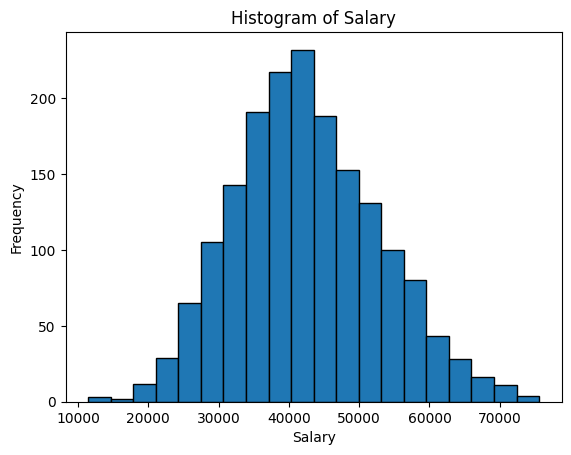

Skewness of salary: 0.27383514161440997 

The salary data appears to be right-skewed, suggesting it may follow a log-normal distribution or a similar distribution with a long tail on the right side.

Mean Salary: 42522.11236418141, Standard Deviation: 10333.139905547336 

Z-scores: lower = -2.1796000605866603, upper = -1.211840009778531 

Probability that salary is between 20000 and 30000: 0.09814325462173654


In [46]:
# Q7: What is the probability that the salary is greater than 20000 and less than 30000 ?

# 1. Identify the distribution by
# Plotting Histogram
plt.hist(df_students['salary'], bins=20, edgecolor='black')
plt.title("Histogram of Salary")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()
# calculate the skewness
salary_skew = df_students['salary'].skew()
print("Skewness of salary:", salary_skew, '\n')
# Which distribution does this data follow?
print("The salary data appears to be right-skewed, suggesting it may follow a log-normal distribution or a similar distribution with a long tail on the right side." '\n')

# 2. Compute mean and std
mean_salary = df_students['salary'].mean()
std_salary = df_students['salary'].std()
print(f"Mean Salary: {mean_salary}, Standard Deviation: {std_salary} \n")

# 3. Convert to Z-scores
lower_z = (20000 - mean_salary) / std_salary
upper_z = (30000 - mean_salary) / std_salary
print(f"Z-scores: lower = {lower_z}, upper = {upper_z} \n")

# 4. Use CDF difference with the use of the right distribution function from scipy.stats
from scipy.stats import norm
probability = norm.cdf(upper_z) - norm.cdf(lower_z)
print(f"Probability that salary is between 20000 and 30000: {probability}")





In [48]:
# Q8: A factory produces 200 chips with defect rate 8%. Answer the following questions:
# 1. What is the distribution name of this problem, based on the following questions ?
print("This problem follows a Binomial distribution, as it involves a fixed number of independent trials (200 chips) with two possible outcomes (defective or not defective) and a constant probability of success (defect rate of 8%).")

# 2. What is the probability of getting exactly 14 defective chips ?
from scipy.stats import binom
n = 200  # number of trials
p = 0.08  # probability of success (defective chip)
k = 14  # number of defective chips
probability_14_defective = binom.pmf(k, n, p)
print(f"Probability of getting exactly 14 defective chips: {probability_14_defective}")

# 3. At least 14 defective ?

probability_at_least_14 = 1 - binom.cdf(13, n, p)
print(f"Probability of getting at least 14 defective chips: {probability_at_least_14}")

# 4. At most 15 defective ?
probability_at_most_15 = binom.cdf(15, n, p)
print(f"Probability of getting at most 15 defective chips: {probability_at_most_15}")

# 5. Expected defects and standard deviation
expected_defects = n * p
std_defects = (n * p * (1 - p))**0.5
print(f"Expected number of defective chips: {expected_defects}")
print(f"Standard deviation of defective chips: {std_defects}")

This problem follows a Binomial distribution, as it involves a fixed number of independent trials (200 chips) with two possible outcomes (defective or not defective) and a constant probability of success (defect rate of 8%).
Probability of getting exactly 14 defective chips: 0.09541156492261971
Probability of getting at least 14 defective chips: 0.7357078859493741
Probability of getting at most 15 defective chips: 0.4625822359332888
Expected number of defective chips: 16.0
Standard deviation of defective chips: 3.8366652186501757
